<a href="https://colab.research.google.com/github/hemajuluri/Ethical-and-fairness/blob/Version2_thesis/02_Interpretation_Semantic_Mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import joblib
import pandas as pd
import os

# 1. Path Configuration
root_path = '/content/drive/MyDrive/Thesis/src/'
artifacts_path = os.path.join(root_path, 'artifacts/')

# 2. Integrity Check: Verify Data Manifest
manifest_path = os.path.join(artifacts_path, 'data_manifest.txt')
if os.path.exists(manifest_path):
    with open(manifest_path, 'r') as f:
        print(f"🔒 Data Integrity Verified: {f.read()}")
else:
    print("⚠️ Warning: Data manifest not found. Integrity cannot be verified.")

# 3. Artifact Retrieval
# Loading the Logistic Regression model and the saved feature names
model = joblib.load(os.path.join(artifacts_path, 'v1_baseline_smote_model.pkl'))
feature_names = joblib.load(os.path.join(artifacts_path, 'feature_names_v2.pkl'))

print(f"✅ Successfully loaded {len(feature_names)} features and the Final Model.")

🔒 Data Integrity Verified: application_train.csv:52e96b895b1112e1c853f670e58372719c8441c5ed1c57ac2f7fad559d784f5f
✅ Successfully loaded 242 features and the Final Model.


In [ ]:
import joblib
import os

# 1. Define your path
artifacts_path = '/content/drive/MyDrive/Thesis/src/artifacts/'

# 2. Load the variables from the files you saved in Notebook 01
X_test_proc = joblib.load(os.path.join(artifacts_path, 'X_test_proc.pkl'))
y_test = joblib.load(os.path.join(artifacts_path, 'y_test.pkl'))
X_test = joblib.load(os.path.join(artifacts_path, 'X_test_original.pkl'))

print(f"✅ Success! 'y_test' is now defined. Total samples: {len(y_test)}")

✅ Success! 'y_test' is now defined. Total samples: 6151


In [ ]:
import numpy as np
# RUN THIS FIRST
denied_indices = np.where(y_test == 1)[0]
sample_size = 500
target_indices = denied_indices[:sample_size]

# This creates the variable 'X_denied_human'
X_denied_human = X_test.iloc[target_indices]

# This creates the variable 'X_denied_raw' as a twin/alias
X_denied_raw = X_denied_human

print(f"✅ Step 1 Complete: Variables are registered.")

✅ Step 1 Complete: Variables are registered.


In [ ]:

# This will now work because y_test is defined!
denied_indices = np.where(y_test == 1)[0]
sample_size = 500
target_indices = denied_indices[:sample_size]

# Create your data tracks
X_denied_math = X_test_proc[target_indices]
X_denied_human = X_test.iloc[target_indices]

print(f"✅ Ready for SHAP extraction on {len(target_indices)} samples.")

✅ Ready for SHAP extraction on 496 samples.


In [ ]:
# Define your "Business Logic" names
semantic_map = {
    'AMT_INCOME_TOTAL': 'Total Annual Income',
    'AMT_CREDIT': 'Requested Loan Amount',
    'DAYS_BIRTH': 'Applicant Age',
    'DAYS_EMPLOYED': 'Years of Employment',
    'NAME_EDUCATION_TYPE': 'Highest Education Level',
    'CNT_CHILDREN': 'Number of Dependents',
    'AMT_ANNUITY': 'Annual Installment Amount'
}

def get_semantic_label(tech_name):
    # Removes scikit-learn prefixes like 'num__' or 'cat__'
    clean_name = tech_name.split('__')[-1]
    return semantic_map.get(clean_name, clean_name)

In [ ]:
import shap

# 1. Initialize the Explainer using the 242-column processed data
# This is the "Math" version that the model understands
explainer = shap.LinearExplainer(model, masker=shap.maskers.Independent(data=X_test_proc))

# 2. Calculate SHAP values for your 496 denied applicants
shap_values = explainer.shap_values(X_denied_math)

print(f"✅ SHAP math complete for {len(shap_values)} applicants.")

✅ SHAP math complete for 496 applicants.


In [ ]:
import pandas as pd

attribution_list = []

for i in range(len(target_indices)):
    individual_shap = shap_values[i]
    # Get the 3 features with the highest positive impact on the denial
    top_3_indices = np.argsort(individual_shap)[-3:][::-1]

    record = {
        'applicant_id': X_denied_human.index[i],
        'gender': X_denied_human['CODE_GENDER'].iloc[i]
    }

    for rank, idx in enumerate(top_3_indices, 1):
        tech_name = feature_names[idx]
        record[f'reason_{rank}'] = get_semantic_label(tech_name)
        record[f'shap_{rank}'] = individual_shap[idx]

        # Pull the actual raw value (like $50,000) from the 120-column data
        clean_name = tech_name.split('__')[-1]
        if clean_name in X_denied_human.columns:
            record[f'value_{rank}'] = X_denied_human[clean_name].iloc[i]
        else:
            record[f'value_{rank}'] = "N/A"

    attribution_list.append(record)

# Save the final "Baton" for Notebook 03
df_attribution_store = pd.DataFrame(attribution_list)
df_attribution_store.to_csv(os.path.join(artifacts_path, 'shap_attribution_store.csv'), index=False)

print("🚀 SUCCESS! Your Attribution Store is ready in your artifacts folder.")

🚀 SUCCESS! Your Attribution Store is ready in your artifacts folder.


### Quick Summary of SHAP Attributions

In [ ]:
# 1. Count the unique reasons for 'reason_1'
print("Unique reasons for 'reason_1':")
display(df_attribution_store['reason_1'].value_counts())


Unique reasons for 'reason_1':


,count
reason_1,
AMT_GOODS_PRICE,134
FLAG_EMP_PHONE,99
Requested Loan Amount,77
Years of Employment,67
EXT_SOURCE_3,32
APARTMENTS_AVG,23
OBS_60_CNT_SOCIAL_CIRCLE,17
EXT_SOURCE_2,16
FLOORSMIN_AVG,13


In [ ]:
# 2. Check for Nulls in reason columns
print("Null counts for reason columns:")
display(df_attribution_store[['reason_1', 'reason_2', 'reason_3']].isnull().sum())

# Also check if any applicant has less than 3 reasons (meaning any nulls)
num_applicants_with_missing_reasons = df_attribution_store[['reason_1', 'reason_2', 'reason_3']].isnull().any(axis=1).sum()
if num_applicants_with_missing_reasons > 0:
    print(f"⚠️ Warning: {num_applicants_with_missing_reasons} applicants have less than 3 reasons.")
else:
    print("✅ All denied applicants have 3 reasons.")


Null counts for reason columns:


,0
reason_1,0
reason_2,0
reason_3,0


✅ All denied applicants have 3 reasons.


Mean shap_1 value by gender:


,shap_1
gender,
F,2.088499
M,1.825015


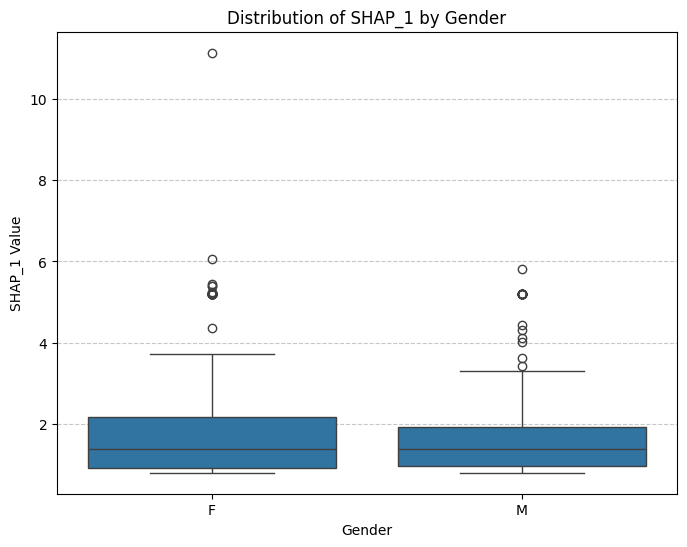

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Correlation Check: Check if gender correlates with the shap_1 value
print("Mean shap_1 value by gender:")
display(df_attribution_store.groupby('gender')['shap_1'].mean())

# Visualize the distribution of shap_1 by gender
fig = plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='shap_1', data=df_attribution_store)
plt.title('Distribution of SHAP_1 by Gender')
plt.xlabel('Gender')
plt.ylabel('SHAP_1 Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
# Load the test data splits
X_test_proc = joblib.load(os.path.join(artifacts_path, 'X_test_proc.pkl'))
y_test = joblib.load(os.path.join(artifacts_path, 'y_test.pkl'))
joblib.dump(X_test, os.path.join(artifacts_path, 'X_test_original.pkl'))

print(f"✅ Loaded test data: {X_test_proc.shape[0]} samples.")

✅ Loaded test data: 6151 samples.


In [ ]:
import numpy as np

# 1. Filter for only the 'Denied' applicants (where TARGET is 1)
denied_indices = np.where(y_test == 1)[0]

# 2. Pick a research sample (e.g., 500) to keep the processing fast
sample_size = 500
target_indices = denied_indices[:sample_size]

# 3. Create the two tracks for these 500 people
X_denied_math = X_test_proc[target_indices]      # For the SHAP calculation
X_denied_human = X_test.iloc[target_indices]   # For the GenAI text

print(f"✅ Success: Ready to extract math from {X_denied_math.shape} and text from {X_denied_human.shape}")

✅ Success: Ready to extract math from (496, 242) and text from (496, 120)


reason_1  AMT_GOODS_PRICE  APARTMENTS_AVG  ELEVATORS_MEDI  EXT_SOURCE_2  \
gender                                                                    
F                      71              15               4             9   
M                      63               8               2             7   

reason_1  EXT_SOURCE_3  FLAG_DOCUMENT_9  FLAG_EMP_PHONE  FLOORSMIN_AVG  \
gender                                                                   
F                   14                0              56              8   
M                   18                1              43              5   

reason_1  FLOORSMIN_MEDI  LANDAREA_MEDI  OBS_60_CNT_SOCIAL_CIRCLE  \
gender                                                              
F                      4              1                         9   
M                      5              0                         8   

reason_1  Requested Loan Amount  YEARS_BEGINEXPLUATATION_MEDI  \
gender                                                      

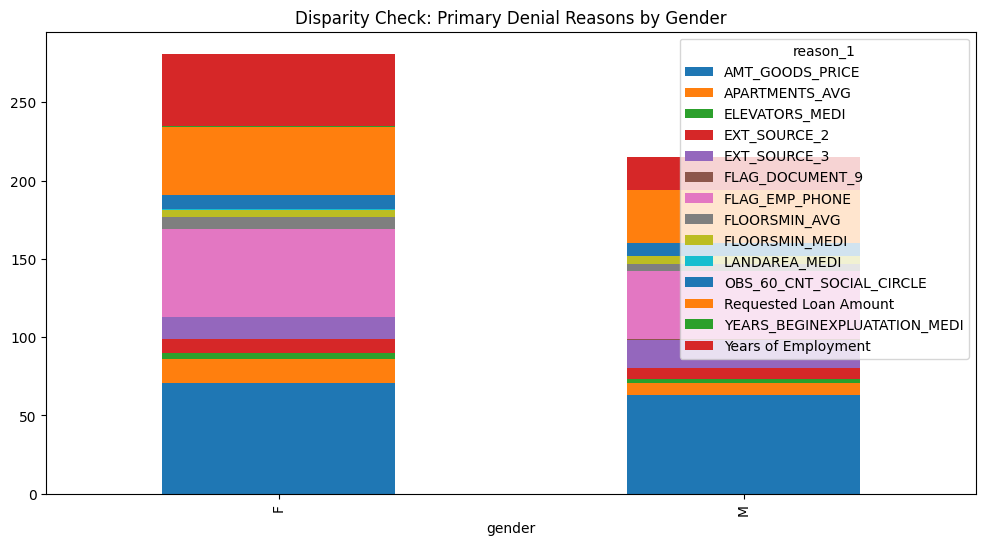

In [ ]:
# Check if the reasons are biased by gender
bias_check = df_attribution_store.groupby(['gender', 'reason_1']).size().unstack(fill_value=0)
print(bias_check)

# Plotting the bias check
bias_check.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Disparity Check: Primary Denial Reasons by Gender')
plt.show()

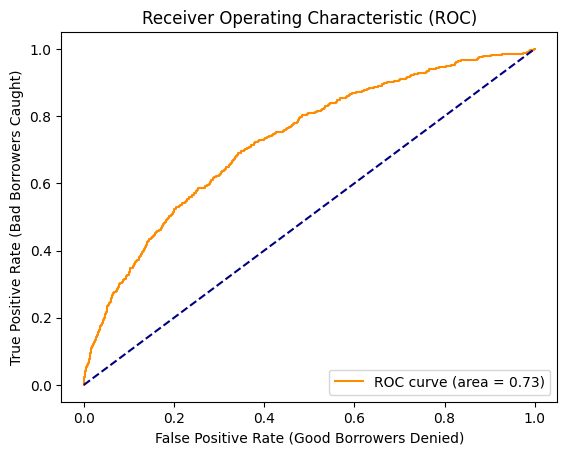

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get probabilities instead of hard predictions
y_probs = model.predict_proba(X_test_proc)[:, 1]

# 2. Calculate ROC data
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# 3. Plotting
plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Random guess line
plt.xlabel('False Positive Rate (Good Borrowers Denied)')
plt.ylabel('True Positive Rate (Bad Borrowers Caught)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

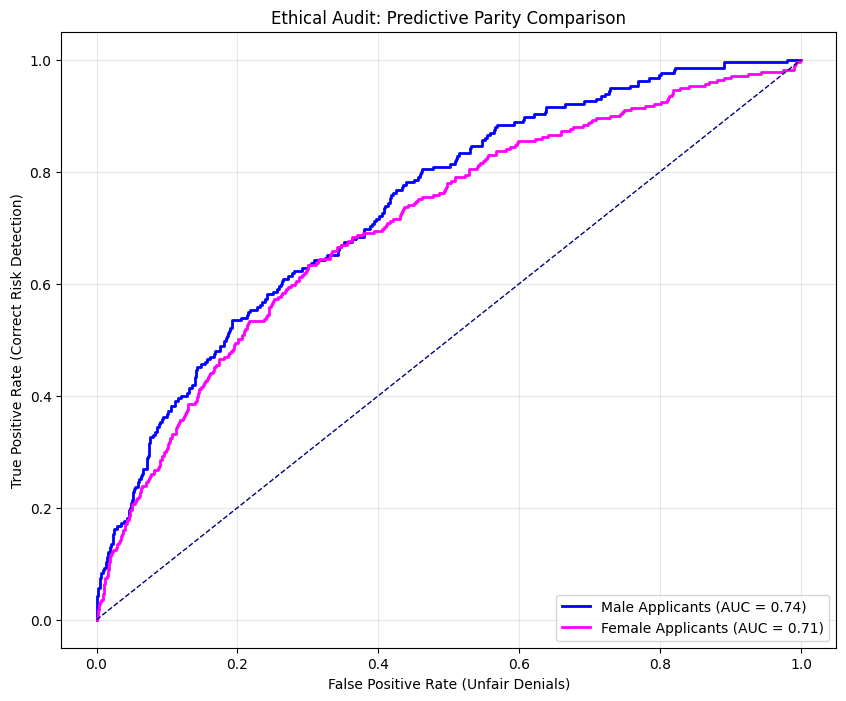

📊 Gender Performance Gap: 0.0319


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get probabilities for the entire test set
# Ensure X_test_proc is the same shape the model was trained on
y_probs = model.predict_proba(X_test_proc)[:, 1]

# 2. Split data based on Gender from your original X_test
# We create a mask to identify where each gender is located
is_male = (X_test['CODE_GENDER'] == 'M').values
is_female = (X_test['CODE_GENDER'] == 'F').values

# 3. Calculate ROC for Males
fpr_m, tpr_m, _ = roc_curve(y_test[is_male], y_probs[is_male])
auc_m = auc(fpr_m, tpr_m)

# 4. Calculate ROC for Females
fpr_f, tpr_f, _ = roc_curve(y_test[is_female], y_probs[is_female])
auc_f = auc(fpr_f, tpr_f)

# 5. Plotting the Comparison
plt.figure(figsize=(10, 8))
plt.plot(fpr_m, tpr_m, color='blue', lw=2, label=f'Male Applicants (AUC = {auc_m:.2f})')
plt.plot(fpr_f, tpr_f, color='magenta', lw=2, label=f'Female Applicants (AUC = {auc_f:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')

plt.xlabel('False Positive Rate (Unfair Denials)')
plt.ylabel('True Positive Rate (Correct Risk Detection)')
plt.title('Ethical Audit: Predictive Parity Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"📊 Gender Performance Gap: {abs(auc_m - auc_f):.4f}")